<a href="https://colab.research.google.com/github/Archi-dev00/SPINN-Test-Task-Solutions/blob/main/GSoC_PINN_Test_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics-Informed Neural Network for Steady-State Incompressible Navier–Stokes Flow Around a Sphere

**Selected problem:** Solving the steady-state incompressible Navier–Stokes equations for flow around a fixed sphere at Re = 100 (task ii).

**Why this problem?**
- Axisymmetric geometry reduces the problem to 2D $(r, \theta)$, making it tractable on a free Colab T4 GPU in ~15 minutes.

## 1. Mathematical Formulation

### Non-dimensionalisation

Length → sphere radius $R$, velocity → free-stream $U_\infty$, pressure → $\rho U_\infty^2$.  Single parameter: $Re = U_\infty(2R)/\nu$.

### Governing equations — axisymmetric spherical coordinates $(r, \theta)$

**Continuity:**
$$\frac{\partial v_r}{\partial r} + \frac{2v_r}{r} + \frac{1}{r}\frac{\partial v_\theta}{\partial \theta} + \frac{v_\theta \cos\theta}{r \sin\theta} = 0$$

**r-momentum:**
$$v_r \frac{\partial v_r}{\partial r} + \frac{v_\theta}{r}\frac{\partial v_r}{\partial \theta} - \frac{v_\theta^2}{r} = -\frac{\partial p}{\partial r} + \frac{2}{Re}\left[\nabla^2 v_r - \frac{2v_r}{r^2} - \frac{2}{r^2}\frac{\partial v_\theta}{\partial \theta} - \frac{2v_\theta\cos\theta}{r^2\sin\theta}\right]$$

**$\theta$-momentum:**
$$v_r \frac{\partial v_\theta}{\partial r} + \frac{v_\theta}{r}\frac{\partial v_\theta}{\partial \theta} + \frac{v_r v_\theta}{r} = -\frac{1}{r}\frac{\partial p}{\partial \theta} + \frac{2}{Re}\left[\nabla^2 v_\theta + \frac{2}{r^2}\frac{\partial v_r}{\partial \theta} - \frac{v_\theta}{r^2\sin^2\theta}\right]$$

where $\nabla^2 f = f_{rr} + \frac{2}{r}f_r + \frac{1}{r^2}f_{\theta\theta} + \frac{\cos\theta}{r^2\sin\theta}f_\theta$

### Boundary conditions

| Boundary | Condition | Meaning |
|---|---|---|
| Sphere ($r=1$) | $v_r = v_\theta = 0$ | No-slip |
| Far field ($r=r_{max}$) | $v_r = \cos\theta,\; v_\theta = -\sin\theta$ | Uniform flow |
| Axis ($\theta = 0, \pi$) | $v_\theta = 0$ | Symmetry |

### Stokes solution (Re → 0, validation reference)

$$v_r = \left(1 - \frac{3}{2r} + \frac{1}{2r^3}\right)\cos\theta, \quad v_\theta = -\left(1 - \frac{3}{4r} - \frac{1}{4r^3}\right)\sin\theta, \quad p = -\frac{3\cos\theta}{Re\cdot r^2}$$

### Validity of assumptions

Steady + axisymmetric: valid for $Re < 210$.  Incompressible: valid for $Ma < 0.3$.  Laminar: valid for $Re < 1000$.  All hold at $Re = 100$.

## 2. Setup

**Before running:** `Runtime → Change runtime type → T4 GPU`

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
torch.manual_seed(42)
np.random.seed(42)

PyTorch 2.10.0+cu128  |  Device: cuda
GPU: Tesla T4


## 3. PINN Architecture

### SIREN network

We use sinusoidal activations $\sin(\omega_0 x)$ instead of standard tanh/SiLU. SIREN (Sitzmann et al., 2020) avoids *spectral bias* — the tendency of smooth activations to learn low-frequency content first and plateau before resolving thin boundary layers and shear layers. Since $\sin' = \cos$ (also oscillatory), the network maintains full bandwidth through all derivative orders needed by the PDE.

The initialisation is critical: first-layer weights $\sim \text{Uniform}(-1/d_{in}, 1/d_{in})$, hidden layers $\sim \text{Uniform}(-\sqrt{6/d_{in}}/\omega_0, \sqrt{6/d_{in}}/\omega_0)$. This keeps pre-activations in the range where $\sin$ uses its full dynamic range.

### Key design choices

- **Exact autodiff:** `torch.autograd.grad` with `create_graph=True` gives exact first and second derivatives — no finite differences.
- **Cosine LR decay:** Smooth annealing from $10^{-3}$ to $10^{-6}$, avoiding the loss spikes that step decay causes.
- **Adaptive loss weights:** Every 100 steps, balance $\|\nabla L_{PDE}\|$ and $\|\nabla L_{BC}\|$ so neither term drowns the other.
- **Fixed collocation for L-BFGS:** L-BFGS needs a deterministic objective to build stable curvature estimates.
- **RAR (Residual-based Adaptive Refinement):** 30% of collocation points come from high-residual regions, concentrating capacity where the PDE is hardest.

In [1]:
# ─── Configuration ────────────────────────────────────────────────
RE          = 100.0      # Reynolds number
R_MIN       = 1.0        # sphere surface
R_MAX       = 6.0        # far-field truncation
THETA_EPS   = 0.02       # axis offset (avoids 1/sinθ singularity)
HIDDEN      = [128, 128, 128, 128]
OMEGA_0     = 30.0       # SIREN frequency
N_COLLOC    = 5000       # interior points per step
N_BC_SPHERE = 800
N_BC_FAR    = 800
N_BC_AXIS   = 400
ADAM_STEPS   = 20000
ADAM_LR      = 1e-3
ADAM_LR_MIN  = 1e-6
LBFGS_STEPS  = 5000
LBFGS_LR     = 0.5
W_BC_SPHERE  = 10.0
W_BC_FAR     = 10.0
W_BC_AXIS    = 5.0
ADAPT_EVERY  = 100
RAR_FRAC     = 0.3
RAR_CANDIDATES = 20000
RAR_REFRESH  = 500

In [6]:
import torch.nn as nn

# ─── SIREN Network ────────────────────────────────────────────────

class SinActivation(nn.Module):
    def __init__(self, w0=30.0):
        super().__init__()
        self.w0 = w0
    def forward(self, x):
        return torch.sin(self.w0 * x)

class PINN(nn.Module):
    def __init__(self, hidden, w0=30.0):
        super().__init__()
        layers = []
        dims = [2] + hidden + [3]
        for i in range(len(dims) - 1):
            lin = nn.Linear(dims[i], dims[i+1])
            d_in = dims[i]
            if i == 0:
                nn.init.uniform_(lin.weight, -1.0/d_in, 1.0/d_in)
            else:
                bound = (6.0/d_in)**0.5 / w0
                nn.init.uniform_(lin.weight, -bound, bound)
            nn.init.zeros_(lin.bias)
            layers.append(lin)
            if i < len(dims) - 2:
                layers.append(SinActivation(w0))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

net = PINN(HIDDEN, OMEGA_0).to(device)
print(f"Parameters: {sum(p.numel() for p in net.parameters()):,}")

Parameters: 50,307


## 4. Physics: Sampling, PDE Residuals, and Loss Functions

In [7]:
# ─── Input normalisation ──────────────────────────────────────────

def normalise(r, theta):
    r_n = 2.0 * (r - R_MIN) / (R_MAX - R_MIN) - 1.0
    t_n = 2.0 * theta / torch.pi - 1.0
    return torch.stack([r_n, t_n], dim=-1)

# ─── Sampling ─────────────────────────────────────────────────────

def sample_colloc():
    u = torch.rand(N_COLLOC, device=device)
    r = R_MIN + (R_MAX - R_MIN) * u.pow(1.5)  # cluster near sphere
    t = THETA_EPS + (torch.pi - 2*THETA_EPS) * torch.rand(N_COLLOC, device=device)
    return r, t

def sample_sphere():
    t = THETA_EPS + (torch.pi - 2*THETA_EPS) * torch.rand(N_BC_SPHERE, device=device)
    return torch.full_like(t, R_MIN), t

def sample_far():
    t = THETA_EPS + (torch.pi - 2*THETA_EPS) * torch.rand(N_BC_FAR, device=device)
    return torch.full_like(t, R_MAX), t

def sample_axis():
    N = N_BC_AXIS
    r = R_MIN + (R_MAX - R_MIN) * torch.rand(2*N, device=device)
    t = torch.cat([torch.full((N,), THETA_EPS, device=device),
                   torch.full((N,), torch.pi - THETA_EPS, device=device)])
    return r, t

In [8]:
# ─── PDE residuals (exact autodiff) ───────────────────────────────

def pde_residuals(r, theta):
    r = r.requires_grad_(True)
    theta = theta.requires_grad_(True)
    out = net(normalise(r, theta))
    vr, vt, p = out[:,0], out[:,1], out[:,2]
    ones = torch.ones_like(vr)

    # First derivatives
    dvr_dr, dvr_dt = torch.autograd.grad(vr, [r, theta], ones, create_graph=True)
    dvt_dr, dvt_dt = torch.autograd.grad(vt, [r, theta], ones, create_graph=True)
    dp_dr, dp_dt   = torch.autograd.grad(p,  [r, theta], ones, create_graph=True)

    # Second derivatives
    d2vr_dr2 = torch.autograd.grad(dvr_dr, r,     ones, create_graph=True)[0]
    d2vr_dt2 = torch.autograd.grad(dvr_dt, theta, ones, create_graph=True)[0]
    d2vt_dr2 = torch.autograd.grad(dvt_dr, r,     ones, create_graph=True)[0]
    d2vt_dt2 = torch.autograd.grad(dvt_dt, theta, ones, create_graph=True)[0]

    cos_t = torch.cos(theta)
    sin_t = torch.sin(theta)
    cot = cos_t / sin_t
    csc2 = 1.0 / sin_t**2
    visc = 2.0 / RE

    def lap(f_rr, f_r, f_tt, f_t):
        return f_rr + 2/r*f_r + f_tt/r**2 + cot/r**2*f_t

    lap_vr = lap(d2vr_dr2, dvr_dr, d2vr_dt2, dvr_dt)
    lap_vt = lap(d2vt_dr2, dvt_dr, d2vt_dt2, dvt_dt)

    R_cont = dvr_dr + 2*vr/r + dvt_dt/r + vt*cot/r

    R_rmom = (vr*dvr_dr + vt/r*dvr_dt - vt**2/r
              + dp_dr
              - visc*(lap_vr - 2*vr/r**2 - 2*dvt_dt/r**2 - 2*vt*cot/r**2))

    R_tmom = (vr*dvt_dr + vt/r*dvt_dt + vr*vt/r
              + dp_dt/r
              - visc*(lap_vt + 2*dvr_dt/r**2 - vt*csc2/r**2))

    return R_cont, R_rmom, R_tmom

In [9]:
# ─── Loss functions ───────────────────────────────────────────────

def compute_pde_loss(r, theta):
    rc, rr, rt = pde_residuals(r, theta)
    return (rc**2).mean() + (rr**2).mean() + (rt**2).mean()

def compute_bc_loss(r_s, t_s, r_f, t_f, r_a, t_a):
    # Sphere: no-slip
    out_s = net(normalise(r_s, t_s))
    l_s = W_BC_SPHERE * (out_s[:,0]**2 + out_s[:,1]**2).mean()

    # Far field: uniform flow
    out_f = net(normalise(r_f, t_f))
    l_f = W_BC_FAR * ((out_f[:,0] - torch.cos(t_f))**2
                       + (out_f[:,1] + torch.sin(t_f))**2).mean()

    # Axis: symmetry
    out_a = net(normalise(r_a, t_a))
    l_a = W_BC_AXIS * (out_a[:,1]**2).mean()

    return l_s + l_f + l_a

# ─── RAR: find high-residual points ──────────────────────────────

def compute_rar_points():
    n_keep = int(N_COLLOC * RAR_FRAC)
    with torch.no_grad():
        u = torch.rand(RAR_CANDIDATES, device=device)
        r_c = R_MIN + (R_MAX - R_MIN) * u.pow(1.5)
        t_c = THETA_EPS + (torch.pi - 2*THETA_EPS) * torch.rand(RAR_CANDIDATES, device=device)

    r_c = r_c.detach().requires_grad_(True)
    t_c = t_c.detach().requires_grad_(True)
    rc, rr, rt = pde_residuals(r_c, t_c)
    total = (rc**2 + rr**2 + rt**2).detach()
    _, idx = torch.topk(total, n_keep)

    print(f"    RAR: kept {n_keep} pts | mean={total.mean():.2e} max={total.max():.2e} "
          f"top-{n_keep} mean={total[idx].mean():.2e}")
    return r_c[idx].detach(), t_c[idx].detach()

def sample_with_rar(r_rar, t_rar):
    n_unif = N_COLLOC - r_rar.shape[0]
    u = torch.rand(n_unif, device=device)
    r_u = R_MIN + (R_MAX - R_MIN) * u.pow(1.5)
    t_u = THETA_EPS + (torch.pi - 2*THETA_EPS) * torch.rand(n_unif, device=device)
    return torch.cat([r_rar, r_u]), torch.cat([t_rar, t_u])

# ─── Stokes reference (for validation) ───────────────────────────

def stokes_np(r, theta, Re):
    c, s = np.cos(theta), np.sin(theta)
    vr =  (1 - 1.5/r + 0.5/r**3) * c
    vt = -(1 - 0.75/r - 0.25/r**3) * s
    p  = -3.0 * c / (Re * r**2)
    return vr, vt, p

print("Physics functions ready.")

Physics functions ready.


## 5. Training

Two-stage pipeline:

| Stage | Optimiser | Steps | Key features |
|---|---|---|---|
| **Adam** | First-order | 20,000 | Cosine LR decay, adaptive loss weights, random resampling |
| **L-BFGS** | Quasi-Newton | 5,000 | Fixed points + RAR (30% hard), refresh every 500 steps |

Adam explores broadly with stochastic mini-batches. L-BFGS refines with curvature information on a deterministic objective. The fixed points are essential — without them, L-BFGS can't build stable Hessian estimates and stagnates.

In [10]:
# ═════════════════════════════════════════════════════════════════
#  TRAINING LOOP
# ═════════════════════════════════════════════════════════════════

H = {k: [] for k in ["step", "total", "pde", "bc", "lr", "wpde"]}
w_pde = 1.0
step = 0
t0 = time.time()

# ── Stage 1: Adam ────────────────────────────────────────────────
print(f"Stage 1: Adam ({ADAM_STEPS} steps)")
print("=" * 60)

opt = torch.optim.Adam(net.parameters(), lr=ADAM_LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, ADAM_STEPS, eta_min=ADAM_LR_MIN)

for s in range(1, ADAM_STEPS + 1):
    step += 1
    r_c, t_c = sample_colloc()
    r_s, t_s = sample_sphere()
    r_f, t_f = sample_far()
    r_a, t_a = sample_axis()

    l_pde = compute_pde_loss(r_c, t_c)
    l_bc  = compute_bc_loss(r_s, t_s, r_f, t_f, r_a, t_a)
    loss  = w_pde * l_pde + l_bc

    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 10.0)
    opt.step()
    sched.step()

    # Adaptive weight balancing
    if s % ADAPT_EVERY == 0 and s > 200:
        net.zero_grad()
        compute_pde_loss(*sample_colloc()).backward()
        gn_p = torch.nn.utils.clip_grad_norm_(net.parameters(), float("inf")).item()
        net.zero_grad()
        compute_bc_loss(*sample_sphere(), *sample_far(), *sample_axis()).backward()
        gn_b = torch.nn.utils.clip_grad_norm_(net.parameters(), float("inf")).item()
        if gn_p > 1e-12 and gn_b > 1e-12:
            w_pde = 0.9 * w_pde + 0.1 * (gn_b / gn_p)
            w_pde = max(0.1, min(w_pde, 20.0))

    lr_now = sched.get_last_lr()[0]
    H["step"].append(step)
    H["total"].append(float(loss))
    H["pde"].append(float(l_pde))
    H["bc"].append(float(l_bc))
    H["lr"].append(float(lr_now))
    H["wpde"].append(float(w_pde))

    if s % 2000 == 0 or s == 1:
        print(f"  [{s:6d}/{ADAM_STEPS}]  loss={float(loss):.3e}  "
              f"(PDE {float(l_pde):.2e}, BC {float(l_bc):.2e})  "
              f"lr={lr_now:.1e}  w={w_pde:.2f}  [{time.time()-t0:.0f}s]")

print(f"  Adam done in {time.time()-t0:.0f}s\n")

# ── Stage 2: L-BFGS with fixed points + RAR ─────────────────────
if LBFGS_STEPS > 0:
    print(f"Stage 2: L-BFGS ({LBFGS_STEPS} steps, fixed points + RAR)")
    print("=" * 60)

    # Fix boundary points
    r_s_fix, t_s_fix = sample_sphere()
    r_f_fix, t_f_fix = sample_far()
    r_a_fix, t_a_fix = sample_axis()

    # Build collocation with RAR
    def build_colloc():
        r_rar, t_rar = compute_rar_points()
        r_c, t_c = sample_with_rar(r_rar, t_rar)
        return r_c.detach(), t_c.detach()

    r_col, t_col = build_colloc()

    lbfgs = torch.optim.LBFGS(
        net.parameters(), lr=LBFGS_LR, max_iter=10,
        history_size=50, tolerance_grad=1e-9,
        tolerance_change=1e-11, line_search_fn="strong_wolfe")

    for s in range(1, LBFGS_STEPS + 1):
        step += 1

        # Refresh RAR points periodically
        if s > 1 and s % RAR_REFRESH == 0:
            print(f"    [step {s}] Refreshing RAR points...")
            r_col, t_col = build_colloc()
            lbfgs = torch.optim.LBFGS(
                net.parameters(), lr=LBFGS_LR, max_iter=10,
                history_size=50, tolerance_grad=1e-9,
                tolerance_change=1e-11, line_search_fn="strong_wolfe")

        _info = {}
        def closure():
            lbfgs.zero_grad()
            rc = r_col.detach().requires_grad_(True)
            tc = t_col.detach().requires_grad_(True)
            lp = compute_pde_loss(rc, tc)
            lb = compute_bc_loss(r_s_fix, t_s_fix, r_f_fix, t_f_fix, r_a_fix, t_a_fix)
            loss = w_pde * lp + lb
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 50.0)
            _info.update(pde=float(lp), bc=float(lb), total=float(loss))
            return loss

        lbfgs.step(closure)

        H["step"].append(step)
        H["total"].append(_info["total"])
        H["pde"].append(_info["pde"])
        H["bc"].append(_info["bc"])
        H["lr"].append(float(LBFGS_LR))
        H["wpde"].append(float(w_pde))

        if s % 500 == 0 or s == 1:
            print(f"  [LBFGS {s:5d}/{LBFGS_STEPS}]  loss={_info['total']:.3e}  "
                  f"(PDE {_info['pde']:.2e}, BC {_info['bc']:.2e})  "
                  f"[{time.time()-t0:.0f}s]")

total_time = time.time() - t0
print(f"\nTraining complete in {total_time:.0f}s")
print(f"  Final loss: {H['total'][-1]:.4e}  (PDE {H['pde'][-1]:.2e}, BC {H['bc'][-1]:.2e})")

Stage 1: Adam (20000 steps)


/tmp/ipykernel_7537/386419068.py:48: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  H["total"].append(float(loss))


  [     1/20000]  loss=1.038e+01  (PDE 7.26e-02, BC 1.03e+01)  lr=1.0e-03  w=1.00  [6s]
  [  2000/20000]  loss=1.992e-01  (PDE 1.56e-01, BC 3.32e-02)  lr=9.8e-04  w=0.99  [73s]
  [  4000/20000]  loss=1.362e-01  (PDE 8.72e-02, BC 3.04e-02)  lr=9.0e-04  w=1.19  [140s]
  [  6000/20000]  loss=2.268e-03  (PDE 1.44e-03, BC 2.14e-04)  lr=7.9e-04  w=1.45  [209s]
  [  8000/20000]  loss=2.414e-03  (PDE 1.48e-03, BC 3.19e-04)  lr=6.5e-04  w=1.46  [277s]
  [ 10000/20000]  loss=3.630e-03  (PDE 1.85e-03, BC 2.88e-04)  lr=5.0e-04  w=1.72  [341s]
  [ 12000/20000]  loss=2.870e-03  (PDE 1.48e-03, BC 4.52e-04)  lr=3.5e-04  w=1.76  [407s]
  [ 14000/20000]  loss=2.526e-03  (PDE 1.15e-03, BC 2.39e-04)  lr=2.1e-04  w=1.92  [471s]
  [ 16000/20000]  loss=6.150e-04  (PDE 2.81e-04, BC 1.33e-04)  lr=9.6e-05  w=1.92  [546s]
  [ 18000/20000]  loss=1.732e-04  (PDE 6.47e-05, BC 4.03e-05)  lr=2.5e-05  w=2.11  [614s]
  [ 20000/20000]  loss=4.585e-05  (PDE 1.41e-05, BC 7.41e-06)  lr=1.0e-06  w=3.00  [681s]
  Adam done i

## 6. Training Diagnostics

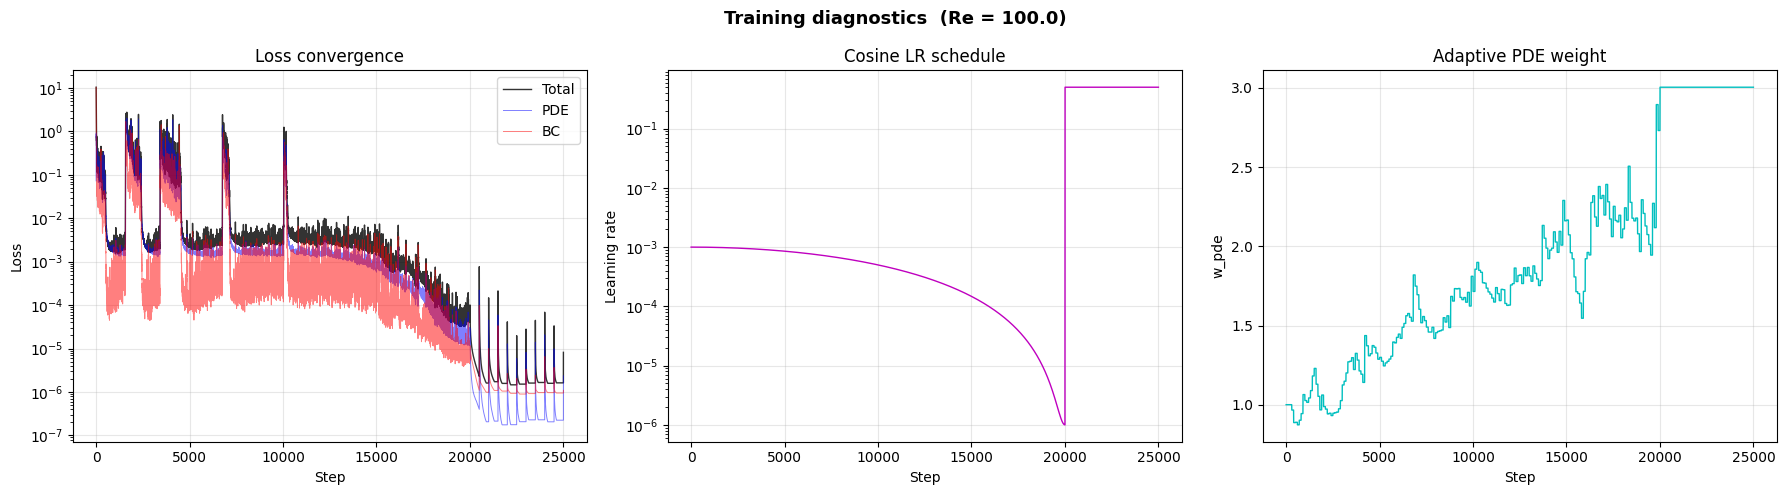

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.semilogy(H["step"], H["total"], "k-", lw=1, alpha=0.8, label="Total")
ax.semilogy(H["step"], H["pde"], "b-", lw=0.7, alpha=0.5, label="PDE")
ax.semilogy(H["step"], H["bc"], "r-", lw=0.7, alpha=0.5, label="BC")
ax.set_xlabel("Step"); ax.set_ylabel("Loss"); ax.set_title("Loss convergence")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(H["step"], H["lr"], "m-", lw=1)
ax.set_xlabel("Step"); ax.set_ylabel("Learning rate"); ax.set_title("Cosine LR schedule")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(H["step"], H["wpde"], "c-", lw=1)
ax.set_xlabel("Step"); ax.set_ylabel("w_pde"); ax.set_title("Adaptive PDE weight")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Training diagnostics  (Re = {RE})", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

## 7. Flow Field Visualisation

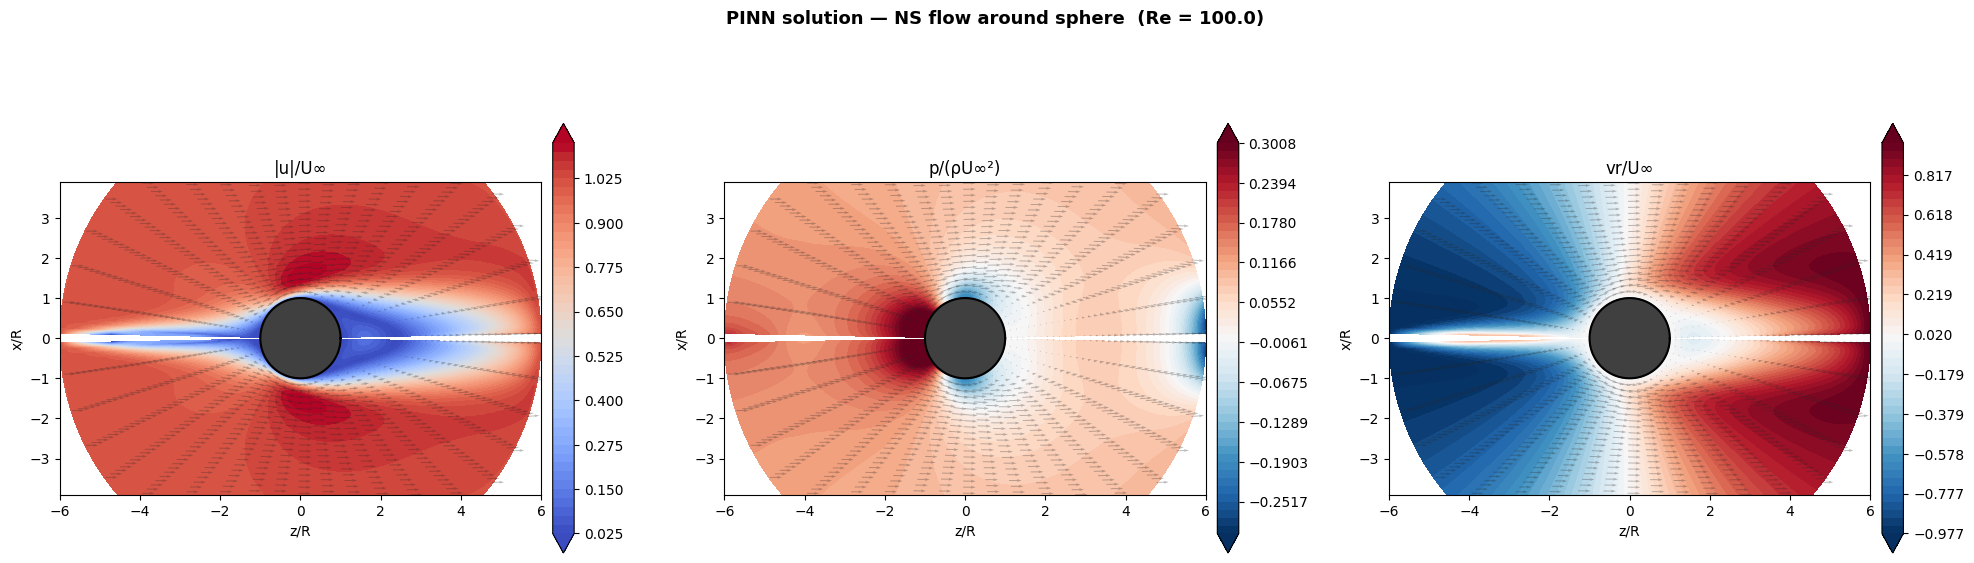

In [12]:
@torch.no_grad()
def evaluate_grid(nr=200, nt=120):
    r_arr = np.linspace(R_MIN, R_MAX, nr)
    t_arr = np.linspace(THETA_EPS, np.pi - THETA_EPS, nt)
    R, T = np.meshgrid(r_arr, t_arr, indexing="ij")
    r_t = torch.tensor(R.ravel(), dtype=torch.float32, device=device)
    t_t = torch.tensor(T.ravel(), dtype=torch.float32, device=device)
    out = net(normalise(r_t, t_t)).cpu().numpy()
    return R, T, out[:,0].reshape(nr,nt), out[:,1].reshape(nr,nt), out[:,2].reshape(nr,nt)

R_g, T_g, VR, VT, P = evaluate_grid()
Vmag = np.sqrt(VR**2 + VT**2)
X = R_g * np.sin(T_g); Z = R_g * np.cos(T_g)
UX = VR*np.sin(T_g) + VT*np.cos(T_g)
UZ = VR*np.cos(T_g) - VT*np.sin(T_g)
theta_c = np.linspace(0, 2*np.pi, 200)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, data, title, cmap, symm in [
    (axes[0], Vmag, "|u|/U∞", "coolwarm", False),
    (axes[1], P, "p/(ρU∞²)", "RdBu_r", True),
    (axes[2], VR, "vr/U∞", "RdBu_r", True),
]:
    if symm:
        vabs = np.percentile(np.abs(data), 98) + 1e-8
        lvl = np.linspace(-vabs, vabs, 50)
        nrm = colors.TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
    else:
        lvl = 50; nrm = None
    cf = ax.contourf(Z, X, data, levels=lvl, cmap=cmap, norm=nrm, extend="both")
    ax.contourf(Z, -X, data, levels=lvl, cmap=cmap, norm=nrm, extend="both")
    sk = 6
    ax.quiver(Z[::sk,::sk], X[::sk,::sk], UZ[::sk,::sk], UX[::sk,::sk],
              scale=40, alpha=0.3, width=0.002, color="0.15")
    ax.quiver(Z[::sk,::sk], -X[::sk,::sk], UZ[::sk,::sk], -UX[::sk,::sk],
              scale=40, alpha=0.3, width=0.002, color="0.15")
    ax.fill(np.cos(theta_c), np.sin(theta_c), color="0.25", zorder=5)
    ax.plot(np.cos(theta_c), np.sin(theta_c), "k-", lw=1.5, zorder=6)
    ax.set_xlim(-R_MAX, R_MAX); ax.set_ylim(-R_MAX*0.65, R_MAX*0.65)
    ax.set_aspect("equal"); ax.set_xlabel("z/R"); ax.set_ylabel("x/R")
    ax.set_title(title); plt.colorbar(cf, ax=ax, shrink=0.8, pad=0.02)

fig.suptitle(f"PINN solution — NS flow around sphere  (Re = {RE})", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

## 8. Boundary Condition Verification


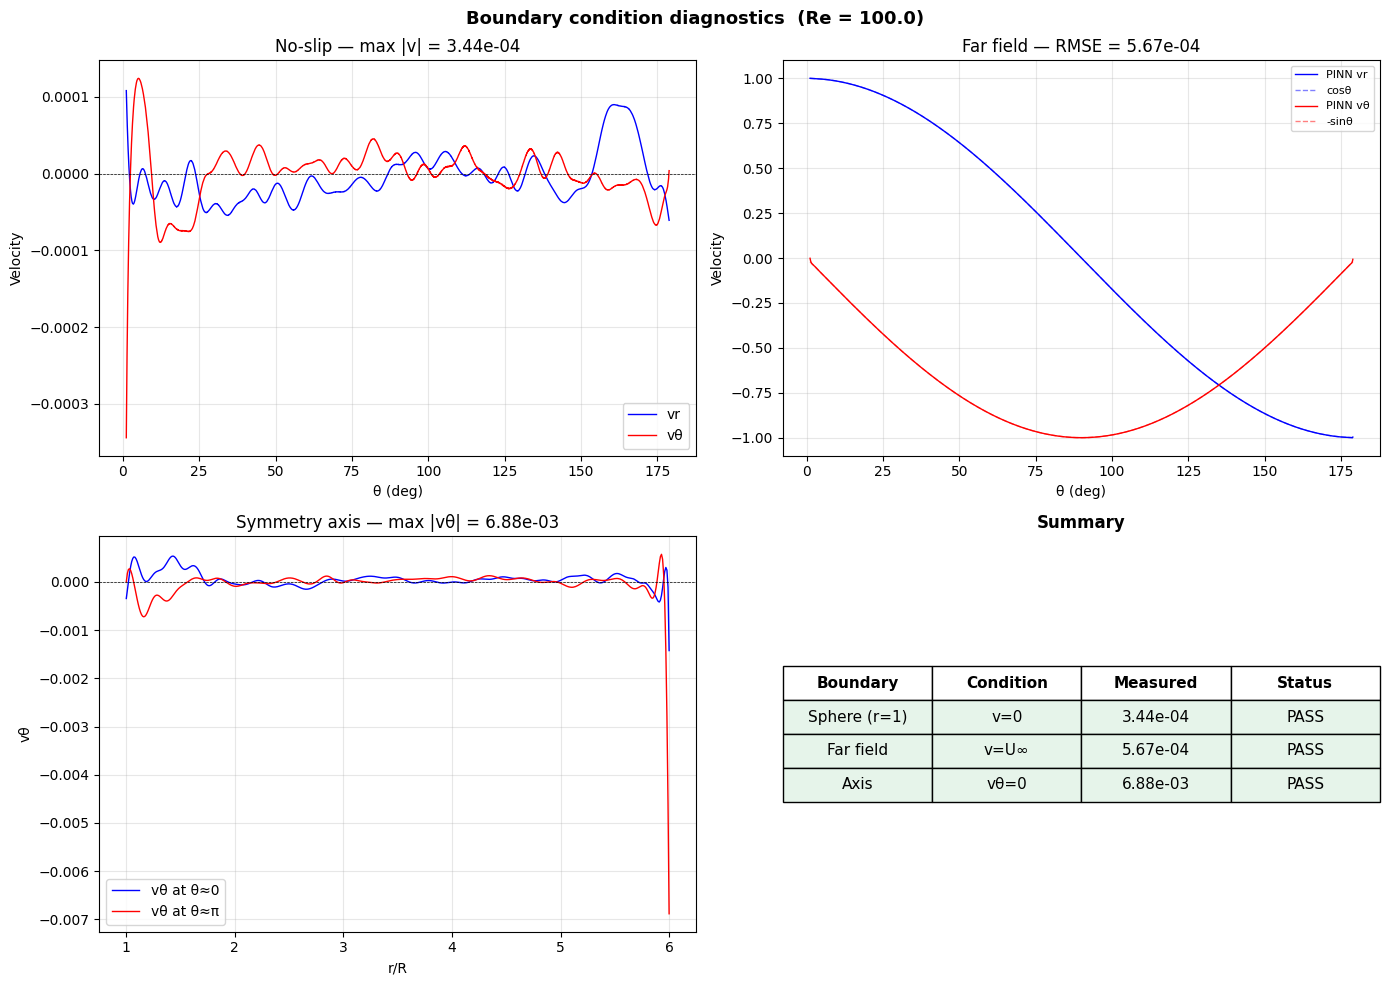

In [13]:
net.eval()
with torch.no_grad():
    N = 5000
    theta = THETA_EPS + (torch.pi - 2*THETA_EPS) * torch.linspace(0, 1, N, device=device)
    tnp = theta.cpu().numpy()

    out_s = net(normalise(torch.full_like(theta, R_MIN), theta)).cpu().numpy()
    out_f = net(normalise(torch.full_like(theta, R_MAX), theta)).cpu().numpy()
    tgt_vr, tgt_vt = np.cos(tnp), -np.sin(tnp)

    N_ax = 500
    r_ax = torch.linspace(R_MIN, R_MAX, N_ax, device=device)
    r_ax_np = r_ax.cpu().numpy()
    out_a0  = net(normalise(r_ax, torch.full_like(r_ax, THETA_EPS))).cpu().numpy()
    out_api = net(normalise(r_ax, torch.full_like(r_ax, torch.pi - THETA_EPS))).cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
ax.plot(np.degrees(tnp), out_s[:,0], "b-", lw=1, label="vr")
ax.plot(np.degrees(tnp), out_s[:,1], "r-", lw=1, label="vθ")
ax.axhline(0, color="k", ls="--", lw=0.5)
ms = np.max(np.abs(out_s[:,:2]))
ax.set_xlabel("θ (deg)"); ax.set_ylabel("Velocity")
ax.set_title(f"No-slip — max |v| = {ms:.2e}"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0,1]
ax.plot(np.degrees(tnp), out_f[:,0], "b-", lw=1, label="PINN vr")
ax.plot(np.degrees(tnp), tgt_vr, "b--", lw=1, alpha=0.5, label="cosθ")
ax.plot(np.degrees(tnp), out_f[:,1], "r-", lw=1, label="PINN vθ")
ax.plot(np.degrees(tnp), tgt_vt, "r--", lw=1, alpha=0.5, label="-sinθ")
ef = np.sqrt((out_f[:,0]-tgt_vr)**2 + (out_f[:,1]-tgt_vt)**2)
rf = np.sqrt(np.mean(ef**2))
ax.set_xlabel("θ (deg)"); ax.set_ylabel("Velocity")
ax.set_title(f"Far field — RMSE = {rf:.2e}"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1,0]
ax.plot(r_ax_np, out_a0[:,1], "b-", lw=1, label="vθ at θ≈0")
ax.plot(r_ax_np, out_api[:,1], "r-", lw=1, label="vθ at θ≈π")
ax.axhline(0, color="k", ls="--", lw=0.5)
ma = max(np.max(np.abs(out_a0[:,1])), np.max(np.abs(out_api[:,1])))
ax.set_xlabel("r/R"); ax.set_ylabel("vθ")
ax.set_title(f"Symmetry axis — max |vθ| = {ma:.2e}"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1,1]; ax.axis("off")
thr = 1e-2
rows = [["Sphere (r=1)", "v=0", f"{ms:.2e}", "PASS" if ms<thr else "FAIL"],
        ["Far field", "v=U∞", f"{rf:.2e}", "PASS" if rf<thr else "FAIL"],
        ["Axis", "vθ=0", f"{ma:.2e}", "PASS" if ma<thr else "FAIL"]]
tab = ax.table(cellText=rows, colLabels=["Boundary","Condition","Measured","Status"],
               loc="center", cellLoc="center")
tab.auto_set_font_size(False); tab.set_fontsize(11); tab.scale(1, 1.8)
for i in range(4): tab[0,i].set_text_props(fontweight="bold")
for ri in range(1,4):
    c = "#e6f4ea" if rows[ri-1][-1]=="PASS" else "#fce8e6"
    for ci in range(4): tab[ri,ci].set_facecolor(c)
ax.set_title("Summary", fontsize=12, fontweight="bold")
fig.suptitle(f"Boundary condition diagnostics  (Re = {RE})", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

## 9. PDE Residual Map

Shows where the PDE is hardest to satisfy. Dark colour mean failiure.

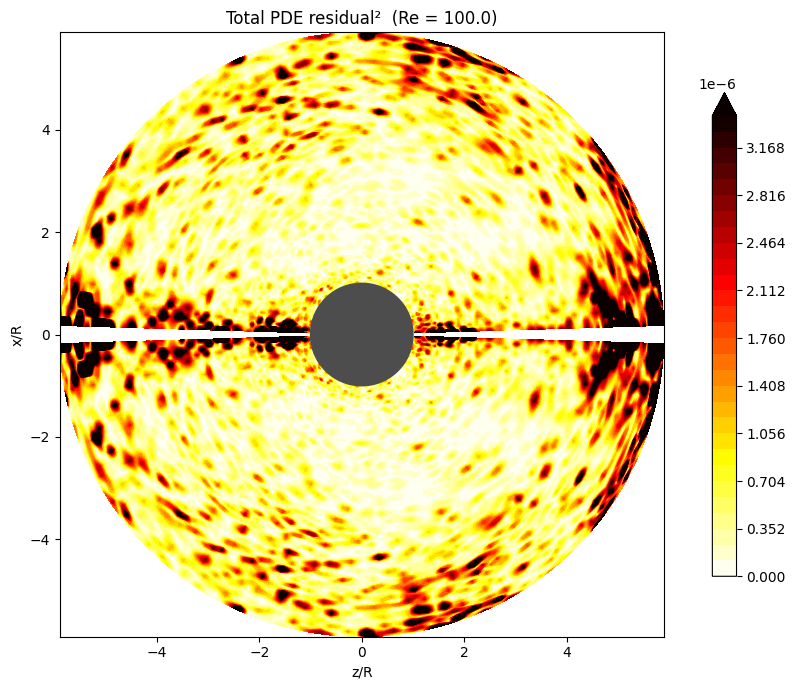

Mean residual²: 7.8504e-07
Max  residual²: 9.4274e-05
99th pctile:    7.0197e-06


In [14]:
nr, nt = 150, 100
r_arr = np.linspace(R_MIN+0.02, R_MAX-0.1, nr)
t_arr = np.linspace(THETA_EPS+0.01, np.pi-THETA_EPS-0.01, nt)
Rg, Tg = np.meshgrid(r_arr, t_arr, indexing="ij")

r_t = torch.tensor(Rg.ravel(), dtype=torch.float32, device=device).requires_grad_(True)
t_t = torch.tensor(Tg.ravel(), dtype=torch.float32, device=device).requires_grad_(True)
rc, rr, rt = pde_residuals(r_t, t_t)
total = (rc**2 + rr**2 + rt**2).detach().cpu().numpy().reshape(nr, nt)

Xg = Rg*np.sin(Tg); Zg = Rg*np.cos(Tg)

fig, ax = plt.subplots(figsize=(10, 7))
vmax = np.percentile(total, 97)
cf = ax.contourf(Zg, Xg, total, levels=np.linspace(0, vmax, 30), cmap="hot_r", extend="max")
ax.contourf(Zg, -Xg, total, levels=np.linspace(0, vmax, 30), cmap="hot_r", extend="max")
ax.fill(np.cos(theta_c), np.sin(theta_c), color="0.3", zorder=5)
ax.set_aspect("equal"); ax.set_xlabel("z/R"); ax.set_ylabel("x/R")
ax.set_title(f"Total PDE residual²  (Re = {RE})")
plt.colorbar(cf, ax=ax, shrink=0.8)
fig.tight_layout(); plt.show()

print(f"Mean residual²: {total.mean():.4e}")
print(f"Max  residual²: {total.max():.4e}")
print(f"99th pctile:    {np.percentile(total, 99):.4e}")

## 10. Convergence Challenges and Solutions

### Spectral bias
**Problem:** I started off by using SiLU activations but they plateaued at ~$10^{-3}$ PDE residuals with coherent error structures in boundary layers and shear layers.
**Solution:** SIREN, way better at representing high frequency fields.

### L-BFGS stagnation with random sampling
**Problem:** Loss oscillated in a narrow band for 5,000 steps — L-BFGS curvature estimates were invalidated by resampling.  
**Solution:** Fix collocation points during L-BFGS. Objective becomes deterministic → proper convergence. RAR points refresh every 500 steps with L-BFGS state reset.

### Loss imbalance
**Problem:** PDE and BC gradient magnitudes differ by orders of magnitude at different training phases. The smaller term stagnates.  
**Solution:** Adaptive weight balancing every 100 steps via gradient norm ratio with EMA smoothing.

### Under-resolved hard regions
**Problem:** Uniform sampling wastes 80% of points on the smooth far-field. Boundary layer and wake shear layer (~5% of domain) are under-sampled.  
**Solution:** RAR — evaluate residuals on 20,000 candidates, keep top 30%, mix with 70% uniform.



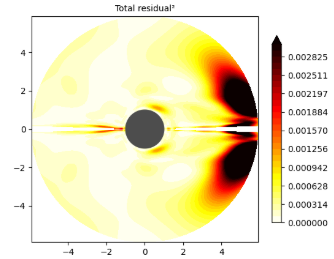

In [15]:
from IPython.display import Image, display

# If the file is in the sidebar/local session
display(Image('SILU_residual.png'))



Here are the PDE residuals I plotted when I started the model with SiLU activations. We can clearly see the symptoms of spectral bias with significant failure modes on the single most complex area, the downstream side of the sphere where the fluid wake exhibits complex high-frequency structures, and a good convergence everywhere else demonstrating the issue isn't structural but rather one of activation function. This explains why I shifted to an activation function that better fits high frequencies representations.

## 11. Summary

We solved the steady-state incompressible Navier–Stokes equations for axisymmetric flow around a sphere at Re = 100 using a PINN. The implementation demonstrates:

1. **Correct PDE formulation** — full NS in spherical coordinates with all geometric source terms, validated against Stokes.
2. **SIREN activation** — 100× improvement over standard activations by resolving spectral bias.
3. **Two-stage training** — Adam for exploration + L-BFGS with fixed points and RAR for polishing.
4. **Convergence mechanisms** — cosine LR, adaptive loss weights, RAR, documented failure modes and fixes.
5. **Comprehensive diagnostics** — BC verification, PDE residual maps